In [1]:
import os
import torch
from torch.utils.data import Dataset
import h5py
import numpy as np
from torch.nn.utils.rnn import pad_sequence
import math
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import math
import numpy as np
import editdistance
import itertools
import matplotlib.pyplot as plt


LOGIT_TO_PHONEME = [
'BLANK',    # "BLANK" = CTC blank symbol
'AA', 'AE', 'AH', 'AO', 'AW',
'AY', 'B', 'CH', 'D', 'DH',
'EH', 'ER', 'EY', 'F', 'G',
'HH', 'IH', 'IY', 'JH', 'K',
'L', 'M', 'N', 'NG', 'OW',
'OY', 'P', 'R', 'S', 'SH',
'T', 'TH', 'UH', 'UW', 'V',
'W', 'Y', 'Z', 'ZH',
' | ',    # "|" = silence token
]

kaggleDirectory = "/kaggle/input/brain-to-text-25/t15_copyTask_neuralData/hdf5_data_final"
maxDays = 1000
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Dataset

In [2]:
class BrainToTextDataset(Dataset):
    def __init__(self, root_dir, split = "train", sessions = None, paths = None):
        self.root_dir = root_dir
        self.split = split
        if paths == None:
            paths = []
            contents = os.listdir(self.root_dir)
            self.max_days = maxDays 
            for item in contents:
                if self.max_days == 0: break
                sessionPath = os.path.join(self.root_dir, item)
                session = sorted(os.listdir(sessionPath))
                if len(session) != 3: continue # skip if not train, val, test in the folder
                    
                data_type = 0 # test
                if split == "train": data_type = 1 
                elif split == "val": data_type = 2
    
                paths.append(os.path.join(sessionPath, session[data_type]))
                self.max_days = self.max_days - 1
                
        self.paths = paths
        
        self.X = []
        for day_idx, train_path in enumerate(paths):
            with h5py.File(train_path, 'r') as f:
                for trial_idx, trial in enumerate(f):
                    
                    X_trial = torch.from_numpy(np.array(f[trial]["input_features"]))
                    y_trial = torch.from_numpy(np.array(f[trial]["seq_class_ids"]))
                    self.X.append({
                        "features": X_trial,   
                        "labels": y_trial,     
                        "day_id": day_idx,     
                        "trial_id": trial_idx  
                    })

    def __len__(self):
        return len(self.X)  # number of trials

    def __getitem__(self, idx):
        return self.X[idx]


## Transformer

In [3]:
def make_subsequent_mask(size):
    mask = torch.triu(torch.ones(size, size), diagonal=1).bool()
    return mask


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=10000):
        #d_model, the dim of the embeddings, ex Hello -> [0.232, -0324, 0.555] means d_model = 3
        #max_len, maximum number of tokens in the sequence this scheme can handle.
        super().__init__()

        """
        lets say d_model = 4, max_len = 3.
        pe = [
            token 0: [element_0, element_1, element_2, element_3],  
            
            token 1: [element_0, element_1, element_2, element_3],  
            
            token 2: [element_0, element_1, element_2, element_3]   
        ]
        """
        pe = torch.zeros(max_len, d_model)                

        #pos is a col vector: [token 0, token 1, token 2]^T (shape = 3 x 1)      
        pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        
        """
        from paper: "Attention Is All You Need", encode each even column with sin(...), and odd with cos(...)
        """
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div_term)
        pe[:, 1::2] = torch.cos(pos * div_term)

        pe = pe.unsqueeze(0)  
        self.pe = pe.to(device)

    def forward(self, x):
        #T is the length of the current x (ie the number of tokens in x)
        T = x.size(1)

        """
        add the positional encoding of x 

        here self.pe will return a matrix of shape [1, T, d_model]
        
        and add it to x, 
        which will create a unique, predictable phase relationship across dimensions so attention can infer relative position using dot products.
        """
        x = x + self.pe[:, :T, :]
        return x
    


class NeuralEncoder(nn.Module):
    def __init__(self, d_model=256, nhead=4, num_layers=4):
        super().__init__()

        #transforms the input of 512 to d_model, here = 256
        self.input_proj = nn.Linear(512, d_model)

        #apply the positional encodings
        self.pos = PositionalEncoding(d_model)

        #Define thge encoder layer, for now a black box
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            batch_first=True
        )
        #save it, 4 encoder layers in this encoder
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

    def forward(self, neural_feature, neural_feature_key_padding_mask=None):
        """
        neural_features: simply the input of shape (512, 1)
        
        neural_feature_key_padding_mask: the mask obtained from the custom collate_fn in the DataLoader.
        masks the padded inputs (the ones that are fake)
        
        """

        neural_feature = self.input_proj(neural_feature)
        neural_feature = self.pos(neural_feature)

        return self.encoder(
            neural_feature,
            src_key_padding_mask=neural_feature_key_padding_mask
        )  # output is memory which the decoder will attend to
    


class NeuralDecoder(nn.Module):
    def __init__(self, vocab_size, d_model=256, nhead=4, num_layers=4, num_days = maxDays):
        super().__init__()

        #embedding layer for the curr input phonemes. This is a wrapper, I still don't understand how it works,
        #but it creates a (256, 1) representation of the input phoneme to then cross attend it with the encoder memory...
        self.embed = nn.Embedding(vocab_size, d_model, padding_idx=0)
        
        #another embedding layer for the current day
        self.day_embed = nn.Embedding(num_days, d_model)
        
        #positonal encoding like in encoder
        self.pos = PositionalEncoding(d_model)

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=nhead,
            batch_first=True
        )
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)

        #map every input projected input vector to a phoneme
        #this is what will actually "do the learning", everything prior only gives context
        self.fc = nn.Linear(d_model, vocab_size)

    def forward(self, class_id, memory, day_idx, class_id_mask = None, class_id_key_padding_mask = None, memory_key_padding_mask = None):
        class_id = self.embed(class_id)

        class_id = self.pos(class_id)
        
        day_vec = self.day_embed(day_idx)       
        day_vec = day_vec.unsqueeze(1)         
        class_id = class_id + day_vec     
        
        out = self.decoder(
            class_id,
            memory,
            tgt_mask=class_id_mask,
            tgt_key_padding_mask=class_id_key_padding_mask,
            memory_key_padding_mask=memory_key_padding_mask
        )
        return self.fc(out)



class NeuralToPhonemeTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=256):
        super().__init__()
        self.encoder = NeuralEncoder(d_model = d_model)
        self.decoder = NeuralDecoder(vocab_size, d_model = d_model)

    def forward(self, neural_feature_input, class_id_tokens, neural_feature_padding_mask, class_id_padding_mask, day_idx):
        # shift right: predict next token
        class_id_in = class_id_tokens[:, :-1]

        seq_len = class_id_in.size(1)
        #this mask is used during self attention so the decoder cant look past its current token
        subsequent_mask = make_subsequent_mask(seq_len).to(class_id_in.device)

        memory = self.encoder(neural_feature_input, neural_feature_key_padding_mask = neural_feature_padding_mask)

        logits = self.decoder(
            class_id_in,
            memory,
            class_id_mask=subsequent_mask,
            #my label sentences are padded right with -1, this makes sure the decoder ignores them 
            class_id_key_padding_mask=class_id_padding_mask[:, :-1],
            #hide the padded features generated by the encoder from the decoder during cross attention
            memory_key_padding_mask=neural_feature_padding_mask,
            day_idx = day_idx
        )
        #print(logits.shape)
        return logits


## Data Loaders

In [4]:
import torch
import torch.nn as nn
import math
import torch.functional as F
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader
import torch.optim as optim

def custom_collate_fn(batch):
    features = [d["features"] for d in batch]
    labels   = [d["labels"] for d in batch]
    day_ids  = [d["day_id"] for d in batch]
    trial_ids = [d["trial_id"] for d in batch]



    padded_features = pad_sequence(features, batch_first=True, padding_value=0)
    padded_labels = pad_sequence(labels, batch_first=True, padding_value=0)

    feature_padding_mask = (padded_features[:,:,0] == 0)  
    label_padding_mask = (padded_labels == 0)            

    return {
        "feature": padded_features,
        "label": padded_labels,
        "feature_mask": feature_padding_mask,
        "label_mask": label_padding_mask,
        "day": torch.tensor(day_ids),
        "trial": torch.tensor(trial_ids)
    }


train_dataset = BrainToTextDataset(root_dir = kaggleDirectory, split='train')
train_dataLoader = DataLoader(train_dataset, batch_size = 16, collate_fn = custom_collate_fn, num_workers=4, pin_memory=True)

val_dataset = BrainToTextDataset(root_dir = kaggleDirectory, split='val', paths = [path.replace("train", "val") for path in train_dataset.paths])
val_dataLoader = DataLoader(val_dataset, batch_size = 16, collate_fn = custom_collate_fn, num_workers=4, pin_memory=True)


In [5]:
len(train_dataset)

7051

In [6]:
len(val_dataset)

1426

## Model and training

In [7]:
model = NeuralToPhonemeTransformer(len(LOGIT_TO_PHONEME)).to(device)

In [8]:
def validation(model, loader, criterion, device):
    model.eval()
    metrics = {}
    metrics['losses'] = []

    day_per = {d: {'total_edit_distance': 0, 'total_seq_length': 0} 
               for d in range(len(loader.dataset.paths))}

    total_edit_distance = 0
    total_seq_length = 0

    with torch.no_grad():
        for batch in loader:
            inputData = batch["feature"].to(device)
            targets = batch["label"].long().to(device)
            feature_mask = batch["feature_mask"].to(device)
            label_mask = batch["label_mask"].to(device)
            day_idx = batch["day"].to(device)

            logits = model(inputData, targets, feature_mask, label_mask, day_idx)
            logits = logits.permute(0, 2, 1)  

            loss = criterion(logits, targets[:, 1:])
            metrics['losses'].append(loss.item())

            batch_size = logits.shape[0]
            seq_lens = (~label_mask).sum(dim=1)  

            #This is taken from the baseline model and how they calculate PER's
            for i in range(batch_size):
                # Predicted sequence
                pred_seq = torch.argmax(logits[i, :, :seq_lens[i]], dim=0).cpu().numpy()
                pred_seq = np.array([x for x, _ in itertools.groupby(pred_seq) if x != 0])

                true_seq = targets[i, 1:seq_lens[i]+1].cpu().numpy()

                edit_dist = editdistance.eval(pred_seq, true_seq)
                total_edit_distance += edit_dist
                total_seq_length += len(true_seq)

                day = day_idx[i].item()
                day_per[day]['total_edit_distance'] += edit_dist
                day_per[day]['total_seq_length'] += len(true_seq)

    avg_PER = total_edit_distance / total_seq_length
    metrics['day_PERs'] = day_per
    metrics['avg_PER'] = avg_PER
    metrics['avg_loss'] = sum(metrics['losses']) / len(metrics['losses'])

    return metrics


In [9]:
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.AdamW(model.parameters(), lr=0.0005)
epochs = 5
model.train()

train_losses = []
val_losses = []
avg_per = []

for epoch in range(epochs):
    for batch_idx, (batch) in enumerate(train_dataLoader):
        inputData = batch["feature"].to(device)
        targets = batch["label"].long().to(device)
        feature_mask = batch["feature_mask"].to(device)
        label_mask = batch["label_mask"].to(device)
        day_idx = batch["day"].to(device)
        
        optimizer.zero_grad() 
        
        logits = model(inputData, targets, feature_mask, label_mask, day_idx)
        logits = logits.permute(0, 2, 1)
        
        loss = criterion(logits, targets[:, 1:])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        

        if batch_idx % 40 == 0:
            metrics = validation(model, val_dataLoader, criterion, device)
            train_losses.append(loss.item())
            val_losses.append(metrics["avg_loss"])
            avg_per.append(metrics["avg_PER"])
            print(f"train loss: {train_losses[-1]} | val loss: {val_losses[-1]} | PER: {avg_per[-1]}")

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:508: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


train loss: 3.7133219242095947 | val loss: 4.434468756781684 | PER: 0.9655488983378431
train loss: 2.915736436843872 | val loss: 2.914840896924337 | PER: 0.7024304213374565
train loss: 2.492126941680908 | val loss: 2.5451221333609686 | PER: 0.6861470815616544
train loss: 2.117730140686035 | val loss: 2.4407056278652615 | PER: 0.6707817935833011
train loss: 2.122525453567505 | val loss: 2.3732004960378013 | PER: 0.6603691534596057
train loss: 2.1665239334106445 | val loss: 2.3102657238642377 | PER: 0.6407276768457673
train loss: 2.211604118347168 | val loss: 2.268555380238427 | PER: 0.6332866254348667
train loss: 2.0370657444000244 | val loss: 2.2396520839797125 | PER: 0.6319337069965211
train loss: 2.088545799255371 | val loss: 2.222407368818919 | PER: 0.6268361035948976
train loss: 1.923554539680481 | val loss: 2.1575025068389047 | PER: 0.6221733668341709
train loss: 2.073763132095337 | val loss: 2.059828029738532 | PER: 0.594535175879397
train loss: 1.8093539476394653 | val loss: 2.0

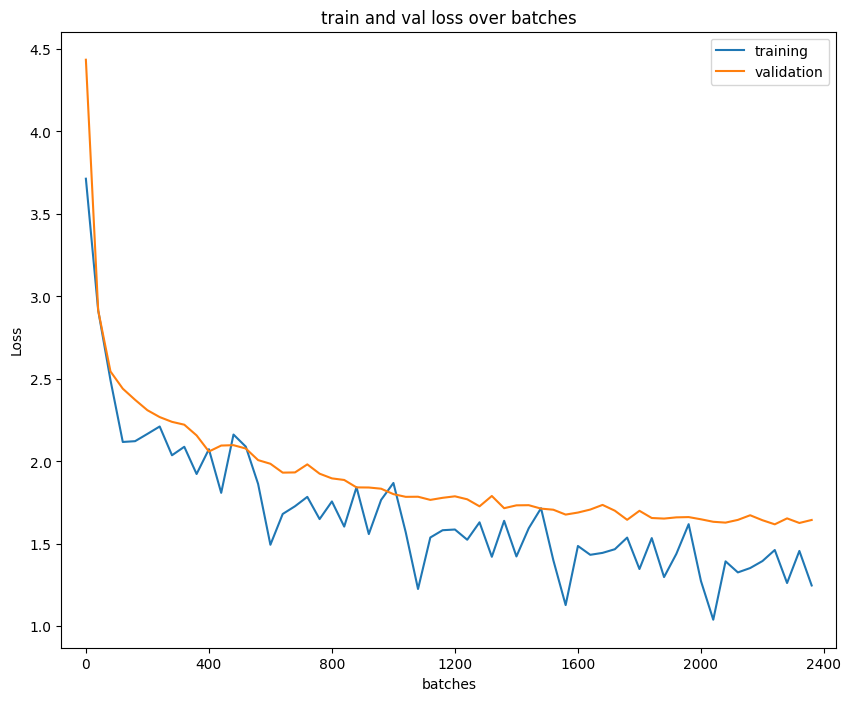

In [21]:
plt.figure(figsize = (10, 8))
plt.plot(range(len(train_losses)), train_losses, label = "training")
plt.plot(range(len(val_losses)), val_losses, label = "validation")
plt.title("train and val loss over batches")
plt.legend()
ticks = plt.xticks()[0]
plt.xticks(ticks, [int(t*40) for t in ticks])
plt.xlim(-2, 61)
plt.xlabel("batches")
plt.ylabel("Loss")
plt.show()

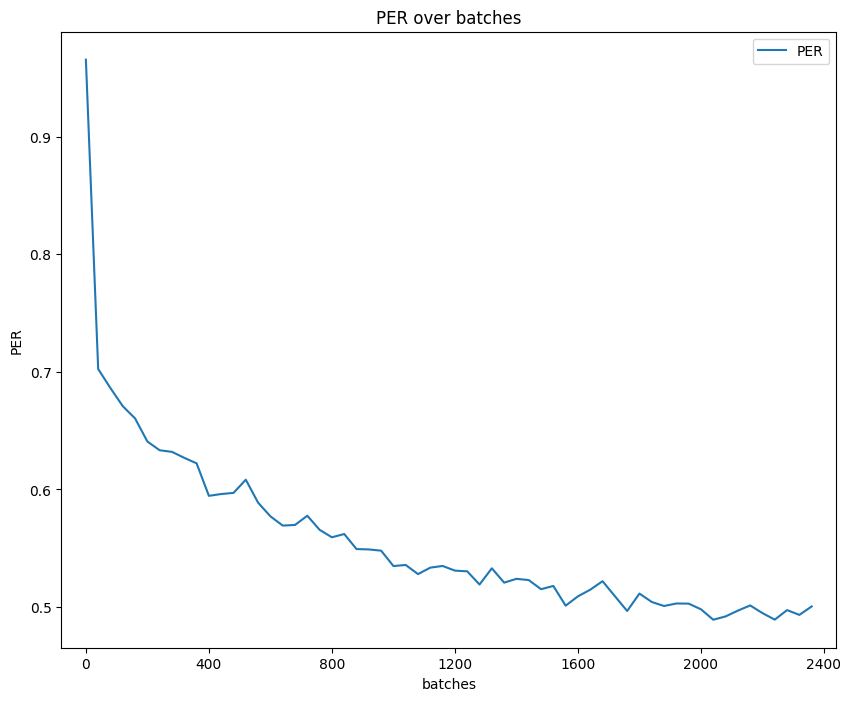

In [22]:
plt.figure(figsize = (10, 8))
plt.plot(range(len(avg_per)), avg_per, label = "PER")
plt.title("PER over batches")
plt.legend()
ticks = plt.xticks()[0]
plt.xticks(ticks, [int(t*40) for t in ticks])
plt.xlim(-2, 61)
plt.xlabel("batches")
plt.ylabel("PER")
plt.show()